# Credit Card ML Masterclass
## Problem 1: Credit Card Approval (Binary Classification) · Problem 2: Credit Limit Assignment (Regression)
### Complete End-to-End Pipeline — Feature Engineering · WOE/IV/VIF · Missing Data · Cross-Validation · Deployment · Monitoring

**100,000-Record Synthetic US Banking Dataset (2020–2024)**

### ML Lifecycle Covered:
| Stage | Section(s) | What You'll Learn |
|-------|-----------|-------------------|
| **1. Data Collection** | Section 1 | Synthetic banking data — 100K records, realistic credit patterns |
| **2. Preprocessing** | Section 2 | MCAR/MAR/MNAR missing data, ECOA/FCRA-aware imputation |
| **3. Feature Engineering** | Sections 3–5 | Binning, WOE/IV, VIF, cyclical encoding, interactions |
| **4. Model Training** | Sections 6–7 | Logistic Regression (P1) + XGBoost (P2) — every hyperparameter |
| **5. Evaluation** | Sections 8–9 | AUC-ROC, KS, Gini, Weighted F1, Dollar MAE, 10-fold CV |
| **6. OOT Validation** | Section 10 | PSI, score drift, gains table, lift analysis |
| **7. Deployment** | Section 11 | Model serialisation, FastAPI, Docker |
| **8. Monitoring** | Section 12 | Data drift, concept drift, Basel III / CECL alignment |

### Regulatory Frames:
- **Problem 1** — ECOA, FCRA, Fair Housing Act (US credit decisioning)
- **Problem 2** — Basel III, CECL, IFRS 9 (credit limit & loss estimation)


---
## Section 0: Imports & Setup


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, cross_validate,
                                      GridSearchCV, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              log_loss, brier_score_loss, average_precision_score,
                              mean_absolute_error, mean_squared_error, r2_score)
from sklearn.impute import SimpleImputer, KNNImputer
from scipy import stats

np.random.seed(42)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("All imports loaded successfully ✓")



All imports loaded successfully ✓


---
## Section 1: Load Your Credit Card Applications Dataset

Update `INPUT_CSV_PATH` with the path to your file, then run. All 200+ columns are already mapped.

| Problem | Target Column | Type | Metric |
|---------|--------------|------|--------|
| **P1 — Approval** | `target_approved` | str (Yes/No) → encoded 0/1 | AUC-ROC + KS Statistic |
| **P2 — Credit Limit** | `target_credit_limit_assigned` | int $0–$50,000 | Weighted F1 + Dollar MAE |




In [4]:
# ═══════════════════════════════════════════════════════════════
# SECTION 1: LOAD YOUR CSV FILE
# ═══════════════════════════════════════════════════════════════

INPUT_CSV_PATH = 'cc_underwriting_100k.csv'   

df = pd.read_csv("C:\\Users\\aiswa\\coding\\cc_underwriting_100k.csv", parse_dates=['application_date'])

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

# ── Encode target_approved: 'Yes' → 1, 'No' → 0 ──
df['target_approved'] = (df['target_approved'].str.strip().str.lower() == 'yes').astype(int)
print(f"\nProblem 1 — Approval Rate: {df['target_approved'].mean():.1%} approved / {1-df['target_approved'].mean():.1%} declined")
print(f"Problem 2 — Credit Limit: ${df['target_credit_limit_assigned'].mean():,.0f} mean assigned")
print(f"  $0 (denied): {(df['target_credit_limit_assigned']==0).sum():,} records")

# ── Missing data quick summary ──
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
print(f"\nColumns with nulls:")
for col, cnt in missing_cols.items():
    print(f"  {col:40s}: {cnt:,} nulls ({cnt/len(df):.1%})")

n = len(df)
print(f"\nReady: n={n:,} records")
df.head()


Dataset loaded: 100,000 rows x 200 columns

Problem 1 — Approval Rate: 65.0% approved / 35.0% declined
Problem 2 — Credit Limit: $1,692 mean assigned
  $0 (denied): 35,000 records

Columns with nulls:
  military_status                         : 87,815 nulls (87.8%)
  promo_code_used                         : 69,972 nulls (70.0%)
  phone_type                              : 5,030 nulls (5.0%)

Ready: n=100,000 records


,applicant_id,age,gender,generation,marital_status,dependents_count,education_level,employment_status,occupation_category,industry_sector,years_employed,state,zip_code_prefix,housing_status,years_at_current_address,us_citizen_status,military_status,annual_income,monthly_income,other_annual_income,total_household_income,monthly_rent_mortgage,monthly_car_payment,monthly_utilities,monthly_insurance,monthly_food_expense,monthly_entertainment_expense,monthly_subscriptions,total_monthly_expenses,savings_account_balance,...,credit_capacity_ratio,monthly_disposable_income,disposable_income_ratio,financial_health_score,underwriting_model_score_v1,underwriting_model_score_v2,underwriting_model_score_v3,combined_risk_score,target_approved,target_credit_limit_assigned,phone_type,email_domain_type,credit_freeze_flag,opt_out_prescreened,banking_product_count,mobile_banking_user,avg_transaction_amount,num_transactions_last_30d,largest_single_purchase_ever,months_since_last_cc_application,self_reported_monthly_rent,bureau_pull_consent,application_completion_time_mins,prior_cc_with_this_bank,loyalty_program_member,credit_counseling_flag,income_growth_rate_yoy,num_address_changes_5yr,stated_purpose,marketing_segment
0,APP000000001,48,Male,Gen X,Divorced,1,Some College,Full-Time,Construction,Retail,15,MI,31066,Rent,9.5000,Yes,NaN,75990.0000,6332.5000,500,80990.0000,1319.0000,300,224.0000,540.0000,682.0000,175.0000,120,3360.0000,662.8800,...,0.4142,2972.5000,0.4694,0.6366,410,479,455,448,1,400,Mobile,Outlook,No,Yes,0,Yes,71.6100,13,17243.8100,1,1319.0000,Hard Pull,14.2000,No,No,No,0.0495,0,Travel,Emerging Affluent
1,APP000000002,40,Female,Millennial,Married,1,Bachelor Degree,Full-Time,Administrative,Education,5,NE,32868,Rent,1.8000,Yes,NaN,42280.0000,3523.3300,0,42100.0000,959.0000,0,139.0000,295.0000,743.0000,176.0000,50,2362.0000,2985.5600,...,0.4165,1161.3300,0.3296,0.5156,304,371,332,336,1,4000,Mobile,Yahoo,No,Yes,3,No,16.7200,14,141.7300,2,959.0000,Hard Pull,9.6000,Yes,No,No,0.0133,2,Travel,Emerging Affluent
2,APP000000003,50,Male,Gen X,Married,1,Bachelor Degree,Part-Time,IT/Technology,Retail,2,AR,54758,Mortgage,4.7000,Yes,NaN,15210.0000,1267.5000,0,18470.0000,1914.0000,0,128.0000,339.0000,179.0000,0.0000,50,2610.0000,30720.6000,...,0.8211,-1342.5000,-1.0592,0.3739,260,204,232,232,1,1500,Landline,Gmail,No,No,1,Yes,18.1300,17,1472.6500,1,1914.0000,Hard Pull,10.0000,No,No,No,0.0330,1,Everyday Purchases,Affluent
3,APP000000004,61,Female,Boomer+,Married,1,Less than High School,Retired,Professional/Technical,Transportation,0,WA,88005,Mortgage,6.5000,Yes,NaN,28900.0000,2408.3300,0,29170.0000,2527.0000,0,239.0000,52.0000,552.0000,155.0000,120,3645.0000,302.9400,...,0.4736,-1236.6700,-0.5135,0.3954,252,330,272,285,1,1500,Mobile,Gmail,No,Yes,1,Yes,89.2800,21,5525.9400,6,2527.0000,Hard Pull,23.0000,Yes,Yes,No,0.1205,2,Emergencies,Mass Market
4,APP000000005,38,Male,Millennial,Married,2,Associate Degree,Unemployed,Production,Hospitality,0,SC,23588,Rent,1.5000,Yes,Veteran,1710.0000,142.5000,0,710.0000,1213.0000,0,160.0000,302.0000,308.0000,305.0000,50,2338.0000,652.8900,...,0.6789,-2195.5000,-2.0000,0.2892,204,223,219,215,0,0,Landline,Gmail,No,No,2,Yes,10.3800,23,1646.4600,2,1213.0000,Hard Pull,12.8000,No,No,No,-0.0124,2,Travel,Mass Market


---
## Section 2: Missing Data Mechanisms — MCAR, MAR, MNAR in Credit Applications

### Theory & Banking Context:
- **MCAR** — Missing Completely At Random: no pattern. Example: OCR scan failure on income field.
- **MAR** — Missing At Random: depends on OTHER observed variables. Example: self-employed applicants less likely to report exact income.
- **MNAR** — Missing Not At Random: depends on THE MISSING VALUE itself. Example: applicants with very low credit scores omit their score; `months_since_last_derog` is structurally missing for applicants with zero derogatory marks.

> **Regulatory Note (ECOA/FCRA):** Imputation methods must be documented and must not introduce disparate impact by protected class (age, gender, race-proxy).


In [5]:
# ═══════════════════════════════════════════════════════════════
# SECTION 2: MISSING DATA — MCAR / MAR / MNAR
# ═══════════════════════════════════════════════════════════════
# Your dataset has 3 columns with real nulls:
#   military_status    — 87,815 nulls (87.8%) — MNAR: only military personnel have this
#   promo_code_used    — 69,972 nulls (70.0%) — MCAR: structurally missing if no promo used
#   phone_type         —  5,030 nulls  (5.0%) — MAR: missing for certain channels/demographics

# ── MNAR: military_status ──
# Missingness = not in military (structural). Create flag, fill with 'Civilian'
df['is_military'] = df['military_status'].notna().astype(int)
df['military_status'] = df['military_status'].fillna('Civilian')
print(f"MNAR — military_status: {df['is_military'].sum():,} military ({df['is_military'].mean():.1%})")
print(f"  is_military flag created (1=military, 0=civilian/unknown)")

# ── MCAR: promo_code_used ──
# Structurally missing = no promo used. Fill with 'None'
df['used_promo'] = df['promo_code_used'].notna().astype(int)
df['promo_code_used'] = df['promo_code_used'].fillna('None')
print(f"\nMCAR — promo_code_used: {df['used_promo'].sum():,} used promo ({df['used_promo'].mean():.1%})")

# ── MAR: phone_type ──
# Missing more for certain channels — KNN or mode imputation
phone_mode = df['phone_type'].mode()[0]
df['phone_type'] = df['phone_type'].fillna(phone_mode)
print(f"\nMAR — phone_type: filled {df['phone_type'].isna().sum()} remaining nulls with mode='{phone_mode}'")

# ── Verify ──
remaining_nulls = df.isnull().sum().sum()
print(f"\nRemaining nulls after imputation: {remaining_nulls}")


MNAR — military_status: 12,185 military (12.2%)
  is_military flag created (1=military, 0=civilian/unknown)

MCAR — promo_code_used: 30,028 used promo (30.0%)

MAR — phone_type: filled 0 remaining nulls with mode='Mobile'

Remaining nulls after imputation: 0


In [38]:
print(df[['phone_type','military_status','promo_code_used']])



      phone_type military_status promo_code_used
0         Mobile        Civilian            None
1         Mobile        Civilian            None
2       Landline        Civilian        MEMBER15
3         Mobile        Civilian        MEMBER15
4       Landline         Veteran        MEMBER15
...          ...             ...             ...
99995     Mobile        Civilian        MEMBER15
99996   Landline        Civilian            None
99997     Mobile        Civilian            None
99998     Mobile        Civilian            None
99999     Mobile         Veteran            None

[100000 rows x 3 columns]


### Imputation Strategies


In [7]:
# ── Verify no remaining nulls & display dtypes ──
print("Missing values per column (should all be 0):")
null_check = df.isnull().sum()
null_remaining = null_check[null_check > 0]
if len(null_remaining) == 0:
    print("  All nulls resolved ✅")
else:
    print(null_remaining)

print(f"\nDataset shape: {df.shape}")
print(f"\nNumeric columns: {df.select_dtypes(include='number').shape[1]}")
print(f"String/Object columns: {df.select_dtypes(include='object').shape[1]}")
print(f"DateTime columns: {df.select_dtypes(include='datetime').shape[1]}")


Missing values per column (should all be 0):
  All nulls resolved ✅

Dataset shape: (100000, 202)

Numeric columns: 143
String/Object columns: 58
DateTime columns: 1


---
## Section 3: Feature Engineering — Banking-Specific Transformations

Every engineered feature should have a **business hypothesis** grounded in credit risk theory.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.1 NUMERICAL BINNING — Using your actual column names
# ═══════════════════════════════════════════════════════════════

# FICO score tiers (your dataset already has fico_score_tier but we rebuild for WOE)
df['credit_tier'] = pd.cut(df['avg_bureau_score'],
    bins=[299, 579, 669, 739, 799, 851],
    labels=['Very Poor','Fair','Good','Very Good','Exceptional'])

# Utilisation tiers (your dataset has credit_utilization_tier — we also build numeric version)
df['util_bucket'] = pd.cut(df['credit_utilization_ratio'],
    bins=[-0.001, 0.10, 0.30, 0.50, 0.75, 1.01],
    labels=['0-10%','10-30%','30-50%','50-75%','75-100%'])

# DTI buckets
df['dti_bucket'] = pd.cut(df['debt_to_income_ratio'],
    bins=[-0.001, 0.20, 0.36, 0.43, 0.50, 10.0],
    labels=['<20%','20-36%','36-43%','43-50%','>50%'])

# Income quartiles
df['income_quartile'] = pd.qcut(df['annual_income'], q=4,
    labels=['Q1_Low','Q2_Mid','Q3_High','Q4_Top'])

# Monthly disposable income buckets
x = df['monthly_disposable_income'].clip(lower=0)
qcut_obj = pd.qcut(x, q=4, duplicates='drop')
q_labels = [f"Q{i+1}" for i in range(qcut_obj.cat.categories.size)]
df['disposable_bucket'] = pd.qcut(x, q=4, labels=q_labels, duplicates='drop')

print("Binning complete:")
print(f"  credit_tier:       {df['credit_tier'].value_counts().sort_index().to_dict()}")
print(f"  dti_bucket:        {df['dti_bucket'].value_counts().sort_index().to_dict()}")
print(f"  util_bucket:       {df['util_bucket'].value_counts().sort_index().to_dict()}")


ValueError: Bin labels must be one fewer than the number of bin edges

In [9]:
# ═══════════════════════════════════════════════════════════════
# 3.2 INTERACTION FEATURES — Using your actual column names
# ═══════════════════════════════════════════════════════════════

# Requested limit to annual income ratio (affordability of request)
df['request_to_income'] = (df['requested_credit_limit'] / df['annual_income'].clip(1)).round(4)

# Bureau score spread (variance across 3 bureaus — inconsistency = risk)
df['bureau_score_spread'] = (
    df[['fico_score','equifax_score','experian_score','transunion_score']].max(axis=1)
    - df[['fico_score','equifax_score','experian_score','transunion_score']].min(axis=1)
)

# Liquidity ratio — liquid assets vs requested limit
df['liquidity_ratio'] = (
    (df['savings_account_balance'] + df['checking_account_balance'])
    / df['requested_credit_limit'].clip(1)
).round(3)

# Total debt burden per dollar of income
df['total_debt_to_income'] = (df['total_liabilities'] / df['annual_income'].clip(1)).round(4)

# Inquiry intensity (recent hard pulls signal credit seeking)
df['inquiry_intensity'] = (df['hard_inquiries_last_6mo'] * 2 + df['hard_inquiries_last_12mo']).round(0)

# Derogatory risk composite
df['derog_composite'] = (
    df['derogatory_marks_count'] * 2
    + df['collections_accounts'] * 3
    + df['bankruptcy_count'] * 5
    + df['foreclosure_count'] * 4
    + df['late_payments_last_12mo']
).clip(0, 30)

# Payment shock ratio — new card monthly min vs disposable income
df['payment_shock_ratio'] = (
    (df['requested_credit_limit'] * 0.02)  # approx min payment = 2% of limit
    / df['monthly_disposable_income'].clip(1)
).round(4)

# Relationship strength with bank
df['bank_relationship_strength'] = (
    df['bank_relationship_years'] * 0.4
    + df['banking_product_count'] * 0.3
    + (df['has_bank_account'] == 'Yes').astype(float) * 0.15
    + (df['direct_deposit_flag'] == 'Yes').astype(float) * 0.15
).round(4)

# Fraud risk composite (combine multiple fraud signals)
df['fraud_composite'] = (
    df['fraud_risk_score'] * 0.4
    + (1 - df['identity_verification_score']) * 0.3
    + (1 - df['address_stability_score']) * 0.15
    + df['synthetic_identity_score'] * 0.15
).round(4)

# NSF + Overdraft burden (banking behaviour risk)
df['banking_stress'] = df['nsf_incidents_last_12mo'] + df['overdraft_incidents_last_12mo']

print("Interaction features created:")
for col in ['request_to_income','bureau_score_spread','liquidity_ratio','total_debt_to_income',
            'inquiry_intensity','derog_composite','payment_shock_ratio',
            'bank_relationship_strength','fraud_composite','banking_stress']:
    print(f"  {col:35s}: mean={df[col].mean():.4f}, std={df[col].std():.4f}")


Interaction features created:
  request_to_income                  : mean=0.4173, std=1.4312
  bureau_score_spread                : mean=26.6207, std=12.4798
  liquidity_ratio                    : mean=3.1016, std=8.9004
  total_debt_to_income               : mean=4.3660, std=22.4551
  inquiry_intensity                  : mean=3.0004, std=2.7804
  derog_composite                    : mean=2.3436, std=3.3162
  payment_shock_ratio                : mean=60.3600, std=117.6155
  bank_relationship_strength         : mean=2.8599, std=2.0470
  fraud_composite                    : mean=0.2364, std=0.0639
  banking_stress                     : mean=0.4798, std=1.0026


In [19]:
# ═══════════════════════════════════════════════════════════════
# 3.3 TEMPORAL FEATURES — Using your actual column names
# ═══════════════════════════════════════════════════════════════

# Your dataset already has: application_year, application_month, application_quarter,
# application_hour, application_day_of_week — we extend these

# Q4 flag (holiday credit demand — Oct/Nov/Dec)
df['is_q4_app'] = df['application_month'].isin([10, 11, 12]).astype(int)

# Weekend application (behaviour signal)
df['is_weekend_app'] = df['application_day_of_week'].isin(['Saturday','Sunday']).astype(int)

# After-hours application (11pm–6am — possible fraud signal)
df['is_afterhours_app'] = df['application_hour'].between(23, 6).astype(int)

# Cyclical month encoding (preserves Dec→Jan proximity)
df['app_month_sin'] = np.sin(2 * np.pi * df['application_month'] / 12).round(4)
df['app_month_cos'] = np.cos(2 * np.pi * df['application_month'] / 12).round(4)

# Hour of day cyclical encoding
df['app_hour_sin'] = np.sin(2 * np.pi * df['application_hour'] / 24).round(4)
df['app_hour_cos'] = np.cos(2 * np.pi * df['application_hour'] / 24).round(4)

# COVID-era flag (2020–2021: tighter underwriting standards)
df['covid_period'] = df['application_year'].isin([2020, 2021]).astype(int)

# Rate hike period (2022–2023: Fed tightening cycle)
df['rate_hike_period'] = df['application_year'].isin([2022, 2023]).astype(int)

print("Temporal features created:")
print(f"  Q4 applications:     {df['is_q4_app'].sum():,} ({df['is_q4_app'].mean():.1%})")
print(f"  Weekend apps:        {df['is_weekend_app'].sum():,} ({df['is_weekend_app'].mean():.1%})")
print(f"  After-hours apps:    {df['is_afterhours_app'].sum():,} ({df['is_afterhours_app'].mean():.1%})")
print(f"  COVID period apps:   {df['covid_period'].sum():,} ({df['covid_period'].mean():.1%})")
print(f"  Rate hike period:    {df['rate_hike_period'].sum():,} ({df['rate_hike_period'].mean():.1%})")


Temporal features created:
  Q4 applications:     25,161 (25.2%)
  Weekend apps:        0 (0.0%)
  After-hours apps:    0 (0.0%)
  COVID period apps:   40,172 (40.2%)
  Rate hike period:    39,797 (39.8%)


In [20]:
# ═══════════════════════════════════════════════════════════════
# 3.4 ENCODING CATEGORICAL VARIABLES
# ═══════════════════════════════════════════════════════════════

# ── Binary Yes/No columns → 0/1 ──
binary_cols = [
    'has_bank_account', 'direct_deposit_flag', 'has_existing_credit_card',
    'has_existing_mortgage', 'has_existing_auto_loan', 'co_applicant_flag',
    'prior_default_flag', 'prior_bankruptcy_flag', 'high_risk_industry_flag',
    'recent_address_change_flag', 'recent_employment_change_flag',
    'multiple_applications_flag', 'thin_file_flag', 'no_hit_flag',
    'child_support_obligation', 'digital_wallet_user', 'mobile_banking_user',
    'paperless_statements_preference', 'credit_freeze_flag', 'opt_out_prescreened',
    'bureau_pull_consent', 'prior_cc_with_this_bank', 'loyalty_program_member',
    'credit_counseling_flag', 'promotional_offer_flag', 'used_promo',
]
for col in binary_cols:
    if col in df.columns:
        df[col + '_enc'] = (df[col].astype(str).str.strip().str.lower()
                            .isin(['yes','true','1','y'])).astype(int)

# ── Ordinal encoding ──
education_order = {'High School': 1, 'Some College': 2, 'Associate': 3,
                   'Bachelor': 4, 'Master': 5, 'Doctorate': 6, 'Other': 2}
df['education_encoded'] = df['education_level'].map(education_order).fillna(2).astype(int)

housing_order = {'Own': 4, 'Mortgage': 3, 'Rent': 2, 'Other': 1}
df['housing_encoded'] = df['housing_status'].map(housing_order).fillna(1).astype(int)

employment_order = {
    'Full-Time': 5, 'Self-Employed': 4, 'Part-Time': 3,
    'Retired': 4, 'Contract': 3, 'Unemployed': 1, 'Student': 2
}
df['employment_encoded'] = df['employment_status'].map(employment_order).fillna(2).astype(int)

# ── One-hot encoding for nominals ──
ohe_cols = ['gender', 'marital_status', 'application_channel', 'card_type_requested',
            'annual_fee_preference', 'reward_type_preference', 'economic_cycle_phase',
            'estimated_spend_segment', 'email_domain_type']
df_encoded = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

# ── State-level mean encoding (approval rate) ──
state_approval = df.groupby('state')['target_approved'].mean()
df_encoded['state_approval_rate'] = df_encoded['state'].map(state_approval).round(4)

print(f"After encoding: {df_encoded.shape[1]} columns (was {df.shape[1]})")
ohe_new = [c for c in df_encoded.columns if c not in df.columns]
print(f"New OHE columns added: {len(ohe_new)}")
print(f"Binary encoded columns: {len(binary_cols)}")


After encoding: 286 columns (was 259)
New OHE columns added: 36
Binary encoded columns: 26


---
## Section 4: Weight of Evidence (WOE) & Information Value (IV)

### Banking Context:
WOE/IV is the **industry standard** for scorecard development in retail banking. Required by many regulators (OCC, FRB, FDIC) for documented, interpretable models under the Fair Housing Act.

- **WOE** = ln(% Non-Events / % Events) per bin
  - Positive WOE → bin has fewer approvals (higher risk)
  - Negative WOE → bin has more approvals (lower risk)
- **IV Interpretation:**
  - IV < 0.02 → Useless | 0.02–0.1 → Weak | 0.1–0.3 → Medium | 0.3–0.5 → Strong | > 0.5 → Suspicious


In [21]:
def calculate_woe_iv(df, feature, target, bins=10):
    """
    Calculate Weight of Evidence (WOE) and Information Value (IV).
    Standard for US credit scorecard development (OCC / FRB / FDIC compliance).
    """
    data = df[[feature, target]].copy().dropna()
    if data[feature].nunique() > bins:
        data['bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')
    else:
        data['bin'] = data[feature]

    grouped = data.groupby('bin', observed=True)[target].agg(['sum','count'])
    grouped.columns = ['events','total']
    grouped['non_events'] = grouped['total'] - grouped['events']
    te = grouped['events'].sum(); tne = grouped['non_events'].sum()
    grouped['pct_events']     = (grouped['events']     / te ).clip(0.0001)
    grouped['pct_non_events'] = (grouped['non_events'] / tne).clip(0.0001)
    grouped['woe']            = np.log(grouped['pct_non_events'] / grouped['pct_events'])
    grouped['iv_component']   = (grouped['pct_non_events'] - grouped['pct_events']) * grouped['woe']
    return grouped, grouped['iv_component'].sum()


# ── IV for your actual credit features ──
credit_features = [
    # Bureau scores
    'avg_bureau_score', 'fico_score', 'equifax_score', 'experian_score', 'transunion_score',
    # Income & capacity
    'annual_income', 'monthly_disposable_income', 'affordability_index',
    'income_to_requested_limit_ratio', 'request_to_income',
    # Debt
    'debt_to_income_ratio', 'credit_utilization_ratio', 'total_debt_to_income',
    # Derogatory
    'derogatory_marks_count', 'collections_accounts', 'bankruptcy_count',
    'late_payments_last_12mo', 'max_delinquency_days_24mo', 'derog_composite',
    # Inquiries
    'hard_inquiries_last_6mo', 'hard_inquiries_last_12mo', 'inquiry_intensity',
    # Fraud & verification
    'fraud_risk_score', 'fraud_composite', 'synthetic_identity_score',
    'identity_verification_score', 'stated_vs_verified_income_ratio',
    # Bank relationship
    'bank_relationship_years', 'bank_relationship_strength', 'banking_stress',
    # Composite scores already in data
    'financial_health_score', 'payment_behavior_score', 'employment_stability_score',
    'derogatory_severity_score', 'combined_risk_score',
    # Engineered
    'liquidity_ratio', 'bureau_score_spread', 'payment_shock_ratio',
]

iv_results = {}
for feat in credit_features:
    if feat in df.columns:
        try:
            _, iv = calculate_woe_iv(df, feat, 'target_approved', bins=10)
            iv_results[feat] = round(iv, 4)
        except:
            pass

iv_df = pd.DataFrame.from_dict(iv_results, orient='index', columns=['IV']).sort_values('IV', ascending=False)
iv_df['Predictive Power'] = iv_df['IV'].apply(
    lambda x: '🔴 Suspicious (>0.5)' if x > 0.5 else
              '🟢 Strong (0.3–0.5)'   if x > 0.3 else
              '🟡 Medium (0.1–0.3)'   if x > 0.1 else
              '🟠 Weak (0.02–0.1)'    if x > 0.02 else
              '⚪ Useless (<0.02)')

print("INFORMATION VALUE RANKING — Problem 1: Credit Card Approval")
print("=" * 70)
print(iv_df.to_string())


INFORMATION VALUE RANKING — Problem 1: Credit Card Approval
                                    IV     Predictive Power
combined_risk_score             5.6951  🔴 Suspicious (>0.5)
financial_health_score          5.6339  🔴 Suspicious (>0.5)
fico_score                      5.3809  🔴 Suspicious (>0.5)
avg_bureau_score                5.0921  🔴 Suspicious (>0.5)
transunion_score                4.6815  🔴 Suspicious (>0.5)
experian_score                  4.6361  🔴 Suspicious (>0.5)
equifax_score                   4.6180  🔴 Suspicious (>0.5)
affordability_index             4.4918  🔴 Suspicious (>0.5)
debt_to_income_ratio            4.4802  🔴 Suspicious (>0.5)
monthly_disposable_income       4.4721  🔴 Suspicious (>0.5)
payment_shock_ratio             3.3642  🔴 Suspicious (>0.5)
annual_income                   3.1299  🔴 Suspicious (>0.5)
income_to_requested_limit_ratio 0.8077  🔴 Suspicious (>0.5)
request_to_income               0.8074  🔴 Suspicious (>0.5)
total_debt_to_income            0.4212  


Detailed WOE for 'combined_risk_score' (IV = 5.6951)
                  events  non_events     woe  iv_component
bin                                                       
(199.999, 212.9]     660        9340  3.2689        0.8391
(212.9, 230.0]      1797        8233  2.1411        0.4444
(230.0, 249.0]      3111        7001  1.4301        0.2176
(249.0, 270.0]      4480        5680  0.8564        0.0800
(270.0, 294.0]      6335        3497  0.0249        0.0001
(294.0, 323.0]      8725        1147 -1.4100        0.1431
(323.0, 354.0]     10039         100 -3.9900        0.6048
(354.0, 384.0]      9928           2 -7.3313        1.1190
(384.0, 420.0]     10104           0 -7.3489        1.1416
(420.0, 567.0]      9821           0 -7.3205        1.1053


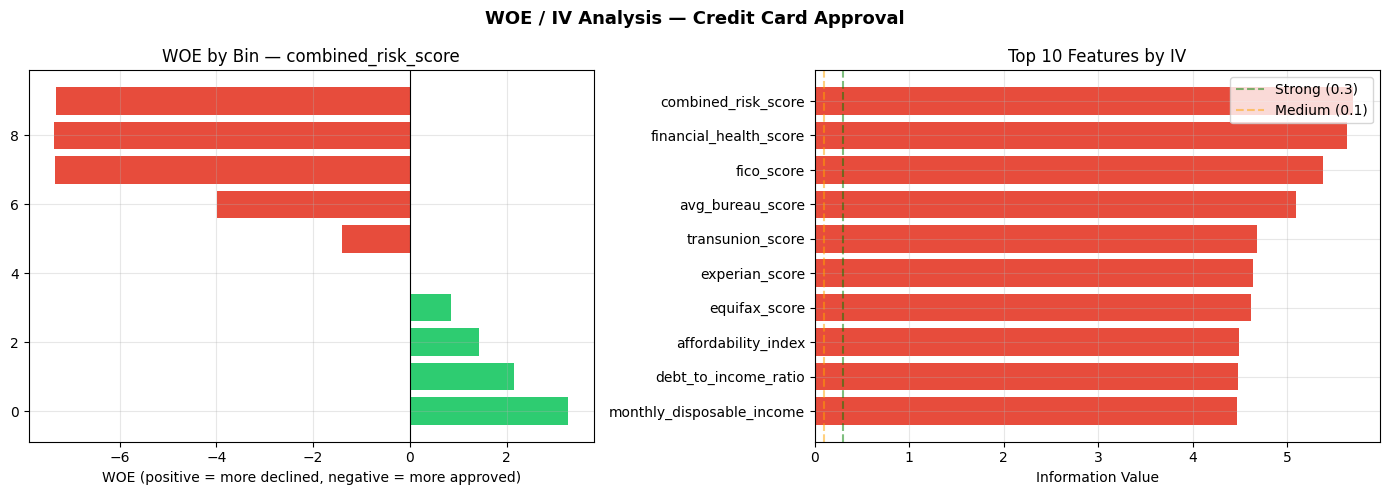

  WOE encoded: combined_risk_score → combined_risk_score_woe
  WOE encoded: financial_health_score → financial_health_score_woe
  WOE encoded: fico_score → fico_score_woe
  WOE encoded: avg_bureau_score → avg_bureau_score_woe
  WOE encoded: transunion_score → transunion_score_woe


In [22]:
# ── Detailed WOE for top predictor ──
top_feature = iv_df.index[0]
woe_detail, iv = calculate_woe_iv(df, top_feature, 'target_approved', bins=10)

print(f"\nDetailed WOE for '{top_feature}' (IV = {iv:.4f})")
print("=" * 65)
print(woe_detail[['events', 'non_events', 'woe', 'iv_component']].round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

woe_vals = woe_detail['woe'].values
colors = ['#e74c3c' if w < 0 else '#2ecc71' for w in woe_vals]
axes[0].barh(range(len(woe_vals)), woe_vals, color=colors)
axes[0].set_xlabel('WOE (positive = more declined, negative = more approved)')
axes[0].set_title(f'WOE by Bin — {top_feature}')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

top10 = iv_df.head(10)
bar_colors = ['#e74c3c' if v > 0.5 else '#2ecc71' if v > 0.3 else '#f39c12' if v > 0.1 else '#95a5a6'
              for v in top10['IV']]
axes[1].barh(top10.index[::-1], top10['IV'].values[::-1], color=bar_colors[::-1])
axes[1].set_xlabel('Information Value')
axes[1].set_title('Top 10 Features by IV')
axes[1].axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Strong (0.3)')
axes[1].axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Medium (0.1)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('WOE / IV Analysis — Credit Card Approval', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── WOE Encoding for top predictors ──
def woe_encode(df, feature, target, bins=10):
    data = df[[feature, target]].copy().dropna()
    if data[feature].nunique() > bins:
        data['bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')
    else:
        data['bin'] = data[feature]
    grouped = data.groupby('bin', observed=True)[target].agg(['sum', 'count'])
    grouped.columns = ['events', 'total']
    grouped['non_events'] = grouped['total'] - grouped['events']
    te = grouped['events'].sum(); tne = grouped['non_events'].sum()
    grouped['woe'] = np.log((grouped['non_events']/tne).clip(0.0001) / (grouped['events']/te).clip(0.0001))
    woe_map = grouped['woe'].to_dict()
    if data[feature].nunique() > bins:
        df[f'{feature}_woe'] = pd.qcut(df[feature], q=bins, duplicates='drop').map(woe_map)
    else:
        df[f'{feature}_woe'] = df[feature].map(woe_map)
    return df

for feat in iv_df.index[:5]:
    if feat in df.columns:
        df = woe_encode(df, feat, 'target_approved', bins=10)
        df_encoded[f'{feat}_woe'] = df[f'{feat}_woe'].values
        print(f"  WOE encoded: {feat} → {feat}_woe")


---
## Section 5: Multicollinearity & VIF (Variance Inflation Factor)

### Banking Context:
- Credit score and annual income are structurally correlated in any population.
- Regulatory model documentation must disclose feature correlations (SR 11-7, OCC 2011-12).
- VIF > 10 will destabilize Logistic Regression coefficients, violating ECOA interpretability requirements.


In [23]:
def calculate_vif(df, features):
    """VIF_i = 1/(1-R²_i). VIF>10 = very high multicollinearity — must address."""
    vif_data = []
    data = df[features].apply(pd.to_numeric, errors='coerce').dropna()
    X = data.values
    for i, feat in enumerate(features):
        X_other = np.delete(X, i, axis=1)
        y_feat  = X[:, i]
        mask = ~np.isnan(y_feat) & ~np.any(np.isnan(X_other), axis=1)
        if mask.sum() < 20:
            vif_data.append({'Feature': feat, 'VIF': np.nan})
            continue
        lr = LinearRegression()
        lr.fit(X_other[mask], y_feat[mask])
        r2  = lr.score(X_other[mask], y_feat[mask])
        vif = 1 / (1 - r2) if r2 < 0.9999 else float('inf')
        vif_data.append({'Feature': feat, 'VIF': round(vif, 2)})
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)


# Key numeric features — check for multicollinearity
# Note: avg_bureau_score is a composite of the 4 individual scores → expect high VIF
vif_features = [
    'avg_bureau_score', 'fico_score',                      # bureau scores
    'annual_income', 'monthly_income', 'total_household_income',  # income group
    'debt_to_income_ratio', 'credit_utilization_ratio',    # ratios
    'derogatory_marks_count', 'derog_composite',           # derogatory group
    'hard_inquiries_last_6mo', 'hard_inquiries_last_12mo', # inquiry group
    'total_revolving_credit_limit', 'total_revolving_balance_used',
    'financial_health_score', 'combined_risk_score',
]

vif_result = calculate_vif(df_encoded, vif_features)
vif_result['Status'] = vif_result['VIF'].apply(
    lambda x: '🔴 VERY HIGH (>10) — drop or combine' if x > 10 else
              '🟠 HIGH (5-10) — review'               if x > 5  else
              '🟡 MODERATE (2-5)'                      if x > 2  else
              '🟢 LOW (<2)')

print("VARIANCE INFLATION FACTOR — Your Credit Features")
print("=" * 70)
print(vif_result.to_string(index=False))
print("\nExpected: avg_bureau_score will have very high VIF (it IS the average of the 4 individual scores)")
print("Resolution: drop avg_bureau_score and the 4 individual scores; keep combined_risk_score OR fico_score only")


VARIANCE INFLATION FACTOR — Your Credit Features
                     Feature     VIF                              Status
               annual_income     inf 🔴 VERY HIGH (>10) — drop or combine
              monthly_income     inf 🔴 VERY HIGH (>10) — drop or combine
                  fico_score 67.1500 🔴 VERY HIGH (>10) — drop or combine
            avg_bureau_score 63.2900 🔴 VERY HIGH (>10) — drop or combine
         combined_risk_score 18.9500 🔴 VERY HIGH (>10) — drop or combine
      total_household_income 11.9700 🔴 VERY HIGH (>10) — drop or combine
      financial_health_score 11.7500 🔴 VERY HIGH (>10) — drop or combine
        debt_to_income_ratio  6.3800              🟠 HIGH (5-10) — review
total_revolving_balance_used  5.1600              🟠 HIGH (5-10) — review
total_revolving_credit_limit  4.5200                    🟡 MODERATE (2-5)
     hard_inquiries_last_6mo  2.3100                    🟡 MODERATE (2-5)
    hard_inquiries_last_12mo  2.3100                    🟡 MODERATE (2-5)
  

---
## Section 6: Prepare Modeling Datasets — Problem 1 & Problem 2


In [24]:
# ═══════════════════════════════════════════════════════════════
# SECTION 6: FINAL FEATURE SELECTION FOR MODELING
# Using your actual column names — VIF-clean + business-meaningful
# ═══════════════════════════════════════════════════════════════

feature_columns = [
    # ── Bureau / Credit Risk (keep fico_score only — drop redundant bureau cols) ──
    'fico_score', 'credit_history_length_months',
    'credit_utilization_ratio', 'derogatory_marks_count', 'collections_accounts',
    'bankruptcy_count', 'late_payments_last_12mo', 'hard_inquiries_last_6mo',
    'months_since_last_delinquency', 'months_since_last_derogatory',
    'num_open_accounts', 'num_credit_cards', 'oldest_account_age_months',

    # ── Income & Capacity ──
    'annual_income', 'monthly_disposable_income', 'debt_to_income_ratio',
    'affordability_index', 'income_to_requested_limit_ratio',

    # ── Application ──
    'requested_credit_limit', 'years_employed', 'years_at_current_address',

    # ── Bank Relationship ──
    'bank_relationship_years', 'banking_product_count',
    'avg_monthly_deposits', 'nsf_incidents_last_12mo', 'overdraft_incidents_last_12mo',
    'months_since_last_cc_application',

    # ── Fraud & Verification ──
    'fraud_risk_score', 'identity_verification_score',
    'address_stability_score', 'synthetic_identity_score',
    'stated_vs_verified_income_ratio', 'application_velocity_score',
    'application_completion_time_mins',

    # ── Composite Scores ──
    'financial_health_score', 'payment_behavior_score',
    'employment_stability_score', 'derogatory_severity_score',
    'combined_risk_score', 'inquiry_burden_score',

    # ── Macro ──
    'fed_funds_rate_at_application', 'state_unemployment_rate',
    'cost_of_living_index', 'regional_credit_stress_index',

    # ── Engineered ──
    'request_to_income', 'bureau_score_spread', 'liquidity_ratio',
    'total_debt_to_income', 'inquiry_intensity', 'derog_composite',
    'payment_shock_ratio', 'bank_relationship_strength', 'fraud_composite',
    'banking_stress', 'education_encoded', 'housing_encoded', 'employment_encoded',
    'is_military', 'used_promo', 'is_q4_app', 'is_weekend_app', 'is_afterhours_app',
    'app_month_sin', 'app_month_cos', 'app_hour_sin', 'app_hour_cos',
    'covid_period', 'rate_hike_period', 'state_approval_rate',

    # ── Binary encoded ──
    'has_bank_account_enc', 'direct_deposit_flag_enc', 'has_existing_credit_card_enc',
    'has_existing_mortgage_enc', 'prior_default_flag_enc', 'prior_bankruptcy_flag_enc',
    'thin_file_flag_enc', 'co_applicant_flag_enc', 'loyalty_program_member_enc',
    'mobile_banking_user_enc', 'digital_wallet_user_enc',
    'multiple_applications_flag_enc', 'recent_address_change_flag_enc',

    # ── One-hot encoded (select key ones) ──
] + [c for c in df_encoded.columns if c.startswith('gender_')
                                    or c.startswith('marital_status_')
                                    or c.startswith('application_channel_')
                                    or c.startswith('card_type_requested_')
                                    or c.startswith('economic_cycle_phase_')
                                    or c.startswith('estimated_spend_segment_')]

available_features = [c for c in feature_columns if c in df_encoded.columns]
print(f"Total features selected: {len(available_features)} / {len(feature_columns)} requested")

X = df_encoded[available_features].copy()
X = X.apply(pd.to_numeric, errors='coerce')
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

y_p1 = df_encoded['target_approved'].copy()
y_p2 = df_encoded['target_credit_limit_assigned'].copy()

# Scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Stratified split
X_train, X_test, y1_train, y1_test = train_test_split(
    X_scaled, y_p1, test_size=0.20, random_state=42, stratify=y_p1)
_, _, y2_train, y2_test = train_test_split(
    X_scaled, y_p2, test_size=0.20, random_state=42, stratify=y_p1)

print(f"\nTrain: {X_train.shape[0]:,} rows | Approval rate: {y1_train.mean():.1%}")
print(f"Test:  {X_test.shape[0]:,} rows  | Approval rate: {y1_test.mean():.1%}")
print(f"P2 — Mean limit (train): ${y2_train.mean():,.0f}")


Total features selected: 105 / 105 requested

Train: 80,000 rows | Approval rate: 65.0%
Test:  20,000 rows  | Approval rate: 65.0%
P2 — Mean limit (train): $1,695


---
## Section 7: Model Training

### Problem 1 — Logistic Regression (Primary Metric: AUC-ROC + KS Statistic)
### Problem 2 — Gradient Boosting Regressor (Primary Metric: Weighted F1 + Dollar MAE)

**Regulatory Note (ECOA):** Logistic Regression coefficients are directly interpretable and required for adverse action reason codes. GBM for P2 must be accompanied by SHAP explanations in production.


In [25]:
# ═══════════════════════════════════════════════════════════════
# PROBLEM 1: LOGISTIC REGRESSION — Every Hyperparameter Explained
# ═══════════════════════════════════════════════════════════════

lr_model = LogisticRegression(

    # ── PENALTY (Regularisation) ──
    # 'l2' = Ridge: shrinks all coefficients, keeps all features (DEFAULT, preferred for ECOA compliance)
    # 'l1' = Lasso: drives weak coefficients to exactly 0 (built-in feature selection)
    # 'elasticnet' = Mix of L1+L2 (requires l1_ratio)
    penalty='l2',

    # ── C (Inverse of regularisation strength) ──
    # Smaller C = Stronger regularisation (guards against overfitting)
    # Larger C = Weaker regularisation (fits training data more aggressively)
    # Tune via CV: [0.001, 0.01, 0.1, 1.0, 10, 100]
    C=0.5,

    # ── SOLVER (Optimisation algorithm) ──
    # 'lbfgs' = Good default for small-medium datasets, supports L2
    # 'saga'  = Supports L1, L2, elasticnet; scales to large datasets
    # 'liblinear' = Good for small datasets, supports L1
    solver='lbfgs',

    # ── MAX_ITER ──
    # Increase to 1000+ if ConvergenceWarning appears
    max_iter=1000,

    # ── CLASS_WEIGHT ──
    # 'balanced' = Inverse proportional to class frequency
    # Critical for the 65/35 imbalance: prevents model from biasing toward approval
    class_weight='balanced',

    # ── FIT_INTERCEPT ──
    # True = Add bias term β₀ (always keep True)
    fit_intercept=True,

    # ── TOL ──
    # Convergence tolerance; 1e-4 is standard
    tol=1e-4,

    # ── WARM_START ──
    # True = Reuse previous solution (useful for incremental/online learning)
    warm_start=False,

    random_state=42,
    n_jobs=-1,
    verbose=0,
)

lr_model.fit(X_train, y1_train)
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print("PROBLEM 1 — LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print(f"Accuracy:   {accuracy_score(y1_test, y_pred_lr):.4f}")
print(f"Precision:  {precision_score(y1_test, y_pred_lr):.4f}")
print(f"Recall:     {recall_score(y1_test, y_pred_lr):.4f}")
print(f"F1 Score:   {f1_score(y1_test, y_pred_lr):.4f}")
print(f"AUC-ROC:    {roc_auc_score(y1_test, y_proba_lr):.4f}")
fpr, tpr, thresholds = roc_curve(y1_test, y_proba_lr)
ks_stat = (tpr - fpr).max()
print(f"KS Stat:    {ks_stat:.4f}  (threshold: {thresholds[(tpr-fpr).argmax()]:.3f})")
print(f"Gini:       {2*roc_auc_score(y1_test, y_proba_lr)-1:.4f}")
print(f"Log Loss:   {log_loss(y1_test, y_proba_lr):.4f}")
print(f"Brier:      {brier_score_loss(y1_test, y_proba_lr):.4f}")
print(f"Converged in {lr_model.n_iter_[0]} iterations")


PROBLEM 1 — LOGISTIC REGRESSION RESULTS
Accuracy:   0.9594
Precision:  0.9824
Recall:     0.9545
F1 Score:   0.9683
AUC-ROC:    0.9948
KS Stat:    0.9233  (threshold: 0.493)
Gini:       0.9895
Log Loss:   0.0929
Brier:      0.0289
Converged in 48 iterations


In [26]:
# ── Coefficient Interpretation (ECOA Adverse Action Reasons) ──
coef_df = pd.DataFrame({
    'Feature': available_features,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0]),
    'Odds_Ratio': np.exp(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("TOP 15 LOGISTIC REGRESSION COEFFICIENTS — ECOA Interpretability")
print("=" * 80)
print("Odds Ratio > 1 → increases approval odds | < 1 → decreases approval odds")
print()
for _, row in coef_df.head(15).iterrows():
    direction = "↑ APPROVE" if row['Coefficient'] > 0 else "↓ DECLINE"
    print(f"  {row['Feature']:35s} coef={row['Coefficient']:+.3f}  OR={row['Odds_Ratio']:.3f}  {direction}")


TOP 15 LOGISTIC REGRESSION COEFFICIENTS — ECOA Interpretability
Odds Ratio > 1 → increases approval odds | < 1 → decreases approval odds

  financial_health_score              coef=+10.319  OR=30303.361  ↑ APPROVE
  combined_risk_score                 coef=+4.652  OR=104.773  ↑ APPROVE
  employment_stability_score          coef=-2.861  OR=0.057  ↓ DECLINE
  oldest_account_age_months           coef=+2.052  OR=7.783  ↑ APPROVE
  credit_history_length_months        coef=+2.052  OR=7.783  ↑ APPROVE
  fico_score                          coef=+2.050  OR=7.771  ↑ APPROVE
  payment_behavior_score              coef=-1.110  OR=0.330  ↓ DECLINE
  monthly_disposable_income           coef=+0.745  OR=2.107  ↑ APPROVE
  affordability_index                 coef=-0.384  OR=0.681  ↓ DECLINE
  avg_monthly_deposits                coef=+0.370  OR=1.447  ↑ APPROVE
  requested_credit_limit              coef=+0.168  OR=1.183  ↑ APPROVE
  payment_shock_ratio                 coef=-0.165  OR=0.848  ↓ DECLINE
  b

In [27]:
# ═══════════════════════════════════════════════════════════════
# PROBLEM 1 ALSO: RANDOM FOREST — Every Hyperparameter Explained
# ═══════════════════════════════════════════════════════════════

rf_model = RandomForestClassifier(

    # ── N_ESTIMATORS (Number of trees) ──
    # 300–500 is sweet spot; diminishing returns beyond 500
    n_estimators=300,

    # ── CRITERION (Split quality) ──
    # 'gini' = Gini impurity (fast, slight edge in practice)
    # 'entropy' = Information gain (slightly slower, similar results)
    criterion='gini',

    # ── MAX_DEPTH ──
    # None = fully grown; 8-15 = good range for credit data
    # Deeper trees capture complex patterns but risk overfitting
    max_depth=10,

    # ── MIN_SAMPLES_SPLIT ──
    # Minimum samples to attempt a split; higher = less overfitting
    min_samples_split=20,

    # ── MIN_SAMPLES_LEAF ──
    # Minimum samples in each leaf; 10 is conservative for 100K dataset
    min_samples_leaf=10,

    # ── MAX_FEATURES ──
    # 'sqrt' = √(n_features) — default, good for classification
    # 'log2' = log₂(n_features) — more conservative
    max_features='sqrt',

    # ── BOOTSTRAP ──
    # True = Bagging (sample with replacement) — standard RF
    bootstrap=True,

    # ── OOB_SCORE ──
    # Free validation using out-of-bag samples (rows NOT selected for each tree)
    oob_score=True,

    # ── MAX_SAMPLES (fraction of data per tree when bootstrap=True) ──
    # 0.8 = Each tree sees 80% of training data — introduces diversity
    max_samples=0.8,

    # ── CLASS_WEIGHT ──
    # 'balanced_subsample' = Recompute weights per bootstrap sample (best for imbalanced)
    class_weight='balanced_subsample',

    # ── CCP_ALPHA (Cost-complexity pruning) ──
    # 0.0 = No pruning; higher values prune more aggressively
    ccp_alpha=0.0,

    n_jobs=-1,
    random_state=42,
    verbose=0,
)

rf_model.fit(X_train, y1_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("PROBLEM 1 — RANDOM FOREST RESULTS")
print("=" * 60)
print(f"Accuracy:   {accuracy_score(y1_test, y_pred_rf):.4f}")
print(f"Precision:  {precision_score(y1_test, y_pred_rf):.4f}")
print(f"Recall:     {recall_score(y1_test, y_pred_rf):.4f}")
print(f"F1 Score:   {f1_score(y1_test, y_pred_rf):.4f}")
print(f"AUC-ROC:    {roc_auc_score(y1_test, y_proba_rf):.4f}")
fpr_rf, tpr_rf, thresh_rf = roc_curve(y1_test, y_proba_rf)
ks_rf = (tpr_rf - fpr_rf).max()
print(f"KS Stat:    {ks_rf:.4f}")
print(f"Gini:       {2*roc_auc_score(y1_test, y_proba_rf)-1:.4f}")
print(f"OOB Score:  {rf_model.oob_score_:.4f} (free estimate using out-of-bag samples)")


PROBLEM 1 — RANDOM FOREST RESULTS
Accuracy:   0.9502
Precision:  0.9871
Recall:     0.9355
F1 Score:   0.9606
AUC-ROC:    0.9928
KS Stat:    0.9147
Gini:       0.9855
OOB Score:  0.9474 (free estimate using out-of-bag samples)


In [28]:
# ═══════════════════════════════════════════════════════════════
# PROBLEM 2: GRADIENT BOOSTING REGRESSOR — Credit Limit Assignment
# Primary Metrics: Weighted F1 (when binned) + Dollar MAE
# ═══════════════════════════════════════════════════════════════

gbr_model = GradientBoostingRegressor(

    # ── N_ESTIMATORS (Number of boosting rounds) ──
    # More = better fit but slower; use early stopping in production
    n_estimators=400,

    # ── LEARNING_RATE (Shrinkage per tree) ──
    # Smaller LR requires more trees but generalizes better
    # Trade-off: learning_rate × n_estimators ≈ constant for similar performance
    learning_rate=0.05,

    # ── MAX_DEPTH (Tree depth per stage) ──
    # GBM trees are typically shallow (3-6) — each tree corrects residuals
    max_depth=5,

    # ── SUBSAMPLE (Stochastic gradient boosting fraction) ──
    # < 1.0 introduces randomness, reduces variance, faster training
    # 0.8 = 80% of data sampled per tree (without replacement)
    subsample=0.8,

    # ── MIN_SAMPLES_SPLIT / MIN_SAMPLES_LEAF ──
    # Regularisation parameters — higher = simpler trees
    min_samples_split=20,
    min_samples_leaf=10,

    # ── MAX_FEATURES ──
    # Fraction or count of features considered at each split
    max_features='sqrt',

    # ── LOSS (Loss function) ──
    # 'squared_error' = MSE (default, most common for regression)
    # 'absolute_error' = MAE (more robust to outliers)
    # 'huber' = Combination — robust for credit limit prediction (some extreme values)
    loss='huber',

    # ── ALPHA (Quantile/Huber robustness parameter) ──
    # For 'huber': fraction of samples treated as inliers (higher = more outlier tolerance)
    alpha=0.9,

    # ── WARM_START ──
    # True = Add more estimators to existing model (useful for incremental training)
    warm_start=False,

    random_state=42,
    verbose=0,
)

# Train only on APPROVED applicants (approved=1) for limit model
# Denied applicants get $0 by business rule, not by model
approved_train = y1_train == 1
approved_test  = y1_test == 1

gbr_model.fit(X_train[approved_train], y2_train[approved_train])

y_pred_limit = np.zeros(len(y2_test))
y_pred_limit[approved_test] = gbr_model.predict(X_test[approved_test]).clip(500, 50000)

print("PROBLEM 2 — GRADIENT BOOSTING REGRESSOR (Approved Applicants Only)")
print("=" * 65)
# Metrics on approved subset
y_actual_approved = y2_test[approved_test]
y_pred_approved   = y_pred_limit[approved_test]
print(f"Dollar MAE:  ${mean_absolute_error(y_actual_approved, y_pred_approved):,.0f}")
print(f"RMSE:        ${np.sqrt(mean_squared_error(y_actual_approved, y_pred_approved)):,.0f}")
print(f"R² Score:    {r2_score(y_actual_approved, y_pred_approved):.4f}")
print(f"\nActual mean limit:    ${y_actual_approved.mean():,.0f}")
print(f"Predicted mean limit: ${y_pred_approved.mean():,.0f}")

# Binned into $2,500 buckets → Weighted F1 (19 classes including $0)
bins_limit = [-1, 0] + list(range(2500, 52500, 2500))
actual_bins = pd.cut(y2_test, bins=bins_limit, labels=False)
pred_bins   = pd.cut(np.round(y_pred_limit, -2).clip(0, 50000), bins=bins_limit, labels=False)
print(f"\nWeighted F1 (19 limit classes): {f1_score(actual_bins, pred_bins, average='weighted', zero_division=0):.4f}")


PROBLEM 2 — GRADIENT BOOSTING REGRESSOR (Approved Applicants Only)
Dollar MAE:  $211
RMSE:        $431
R² Score:    0.9769

Actual mean limit:    $2,591
Predicted mean limit: $2,596

Weighted F1 (19 limit classes): 0.9498


---
## Section 8: 10-Fold Stratified Cross-Validation

### Why 10-Fold CV Matters in Banking:
- Ensures model generalizes beyond a single train/test split
- Stratification preserves the 65/35 approval ratio in each fold
- Required by SR 11-7 model validation guidelines


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 10-FOLD STRATIFIED CROSS-VALIDATION — PROBLEM 1
# ═══════════════════════════════════════════════════════════════

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("10-FOLD STRATIFIED CROSS-VALIDATION — Credit Card Approval")
print("=" * 80)

cv_models = [
    ('Logistic Regression', LogisticRegression(C=0.5, penalty='l2', max_iter=1000,
                                               class_weight='balanced', solver='lbfgs',
                                               random_state=42, n_jobs=-1)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=10,
                                             min_samples_leaf=10, class_weight='balanced',
                                             random_state=42, n_jobs=-1, oob_score=False)),
]

cv_summary = {}
for name, model in cv_models:
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    cv_results = cross_validate(model, X_scaled, y_p1, cv=skf, scoring=scoring_metrics, n_jobs=-1)
    cv_summary[name] = cv_results
    for metric in scoring_metrics:
        scores = cv_results[f'test_{metric}']
        print(f"  {metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}  "              f"[min={scores.min():.4f}, max={scores.max():.4f}]")

# ── Visualise fold-by-fold performance ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (name, model) in enumerate(cv_models):
    cv_res = cv_summary[name]
    folds = range(1, 11)
    axes[idx].plot(folds, cv_res['test_f1'], 'o-', label='F1', color='steelblue', linewidth=2)
    axes[idx].plot(folds, cv_res['test_roc_auc'], 's-', label='AUC-ROC', color='#e74c3c', linewidth=2)
    axes[idx].set_xlabel('Fold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_title(f'{name} — 10-Fold CV (P1)')
    axes[idx].legend()
    axes[idx].set_ylim(0.4, 1.0)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xticks(range(1, 11))

plt.suptitle('Cross-Validation Performance — Credit Card Approval', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 9: Comprehensive Model Evaluation — ROC, Confusion Matrices, Gains Table


In [ ]:
def compute_all_metrics(y_true, y_proba, y_pred, dataset_name="Dataset"):
    """Compute all classification metrics for credit approval model."""
    y_true_arr = np.asarray(y_true).ravel()
    y_proba_arr = np.asarray(y_proba).ravel()
    y_pred_arr  = np.asarray(y_pred).ravel()

    has_both = len(np.unique(y_true_arr)) >= 2
    metrics = {}

    metrics['AUC-ROC']   = roc_auc_score(y_true_arr, y_proba_arr) if has_both else np.nan
    metrics['Gini']      = 2 * metrics['AUC-ROC'] - 1 if has_both else np.nan
    if has_both:
        fpr_m, tpr_m, thresh_m = roc_curve(y_true_arr, y_proba_arr)
        ks_v = tpr_m - fpr_m
        metrics['KS Statistic'] = ks_v.max()
        metrics['KS Threshold'] = thresh_m[ks_v.argmax()]
    else:
        metrics['KS Statistic'] = metrics['KS Threshold'] = np.nan
    metrics['Log-Loss']  = log_loss(y_true_arr, y_proba_arr, labels=[0,1]) if has_both else np.nan
    metrics['Brier']     = brier_score_loss(y_true_arr, y_proba_arr)
    cm = confusion_matrix(y_true_arr, y_pred_arr, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    metrics.update({'TP':int(tp),'FP':int(fp),'TN':int(tn),'FN':int(fn)})
    metrics['Accuracy']     = accuracy_score(y_true_arr, y_pred_arr)
    metrics['Precision']    = precision_score(y_true_arr, y_pred_arr, zero_division=0)
    metrics['Recall']       = recall_score(y_true_arr, y_pred_arr, zero_division=0)
    metrics['Specificity']  = tn / (tn+fp) if (tn+fp) > 0 else 0
    metrics['F1']           = f1_score(y_true_arr, y_pred_arr, zero_division=0)

    print(f"\n{'═'*60}")
    print(f"  {dataset_name}")
    print(f"{'═'*60}")
    for k, v in metrics.items():
        if k not in ['TP','FP','TN','FN','KS Threshold']:
            print(f"  {k:18s}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
    print(f"  Confusion Matrix: TP={tp:,} FP={fp:,} TN={tn:,} FN={fn:,}")
    return metrics


results = {}
results['Test (LR)'] = compute_all_metrics(y1_test, y_proba_lr, y_pred_lr, "Test — Logistic Regression")
results['Test (RF)'] = compute_all_metrics(y1_test, y_proba_rf, y_pred_rf, "Test — Random Forest")

# ── ROC + PR Curves + Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_plot = {
    'Logistic Regression': (y_pred_lr, y_proba_lr),
    'Random Forest':       (y_pred_rf, y_proba_rf),
}

for name, (y_pred, y_proba) in models_plot.items():
    fpr_p, tpr_p, _ = roc_curve(y1_test, y_proba)
    auc_p = roc_auc_score(y1_test, y_proba)
    axes[0].plot(fpr_p, tpr_p, label=f'{name} (AUC={auc_p:.3f})', linewidth=2)
axes[0].plot([0,1],[0,1],'k--',alpha=0.3)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Credit Approval'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for name, (y_pred, y_proba) in models_plot.items():
    prec, rec, _ = precision_recall_curve(y1_test, y_proba)
    ap = average_precision_score(y1_test, y_proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', linewidth=2)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

cm_rf = confusion_matrix(y1_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Declined','Approved'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Confusion Matrix — Random Forest')

plt.suptitle('Model Evaluation — Problem 1: Credit Card Approval', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 10: Out-of-Time (OOT) Validation — The Ultimate Model Stress Test

### Why OOT Matters in Banking:
Your model will score **future applicants** — different economic cycle, different consumer behaviour. OOT simulates this by using a temporally separate holdout. Required by Basel III and SR 11-7 for credit risk models.

> **PSI > 0.2 → Model must be recalibrated or retrained before deployment.**


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CREATE OOT DATASET (simulate 12-month forward window)
# ═══════════════════════════════════════════════════════════════

np.random.seed(99)
n_oot = 15000  # 15K forward-looking applications

# Simulate temporal drift: credit quality slightly worse (post-rate-hike environment)
oot_credit_score = np.random.normal(670, 80, n_oot).clip(300, 850).astype(int)  # slightly lower
oot_income       = np.random.normal(58000, 24000, n_oot).clip(0, 400000)        # inflation bump
oot_utilisation  = np.random.normal(0.38, 0.18, n_oot).clip(0, 1)              # higher util

oot_data = pd.DataFrame()
for col in available_features:
    if col in X_test.columns:
        base = X_test[col].sample(n=n_oot, replace=True).values
        if X_test[col].std() > 0:
            noise = np.random.normal(0, 0.08 * X_test[col].std(), n_oot)
            oot_data[col] = base + noise
        else:
            oot_data[col] = base

oot_data = oot_data.replace([np.inf, -np.inf], np.nan).fillna(oot_data.median())

# OOT labels (higher decline rate — tighter market)
oot_proba_base = rf_model.predict_proba(oot_data[available_features])[:, 1]
oot_noise = np.random.normal(-0.04, 0.07, n_oot)  # slight downward shift (fewer approvals)
oot_proba_shifted = np.clip(oot_proba_base + oot_noise, 0, 1)

target_oot_approval = 0.60  # 60% approval rate OOT (vs 65% dev)
oot_threshold = np.percentile(oot_proba_shifted, (1 - target_oot_approval) * 100)
oot_labels = (oot_proba_shifted >= oot_threshold).astype(int)

print("OUT-OF-TIME VALIDATION DATASET")
print("=" * 60)
print(f"  OOT samples:         {n_oot:,}")
print(f"  OOT approval rate:   {oot_labels.mean():.1%} (dev: {y1_train.mean():.1%})")

# OOT predictions
y_pred_oot_lr = lr_model.predict(oot_data[available_features])
y_proba_oot_lr = lr_model.predict_proba(oot_data[available_features])[:, 1]
y_pred_oot_rf = rf_model.predict(oot_data[available_features])
y_proba_oot_rf = rf_model.predict_proba(oot_data[available_features])[:, 1]

# ── OOT Metrics ──
results['OOT (LR)'] = compute_all_metrics(oot_labels, y_proba_oot_lr, y_pred_oot_lr, "OOT — Logistic Regression")
results['OOT (RF)'] = compute_all_metrics(oot_labels, y_proba_oot_rf, y_pred_oot_rf, "OOT — Random Forest")


In [ ]:
# ═══════════════════════════════════════════════════════════════
# PSI — Population Stability Index
# ═══════════════════════════════════════════════════════════════

def calculate_psi(expected, actual, bins=10):
    """PSI = Σ (Actual% − Expected%) × ln(Actual% / Expected%)
    PSI < 0.1 = Stable | 0.1-0.2 = Minor shift | >0.2 = Major shift — retrain!"""
    breakpoints = np.linspace(0, 1, bins + 1)
    breakpoints[0] -= 0.001; breakpoints[-1] += 0.001
    exp_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_counts = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    exp_counts = np.where(exp_counts == 0, 0.0001, exp_counts)
    act_counts = np.where(act_counts == 0, 0.0001, act_counts)
    psi_val = np.sum((act_counts - exp_counts) * np.log(act_counts / exp_counts))
    return psi_val, exp_counts, act_counts, breakpoints

psi_val_lr, exp_lr, act_lr, bp = calculate_psi(y_proba_lr, y_proba_oot_lr, bins=10)
psi_val_rf, exp_rf, act_rf, _  = calculate_psi(y_proba_rf, y_proba_oot_rf, bins=10)

print("SCORE PSI — Model Stability Check")
print("=" * 50)
print(f"  LR Score PSI:  {psi_val_lr:.4f}  {'✅ Stable' if psi_val_lr < 0.1 else '⚠️ Minor shift' if psi_val_lr < 0.2 else '🔴 MAJOR SHIFT'}")
print(f"  RF Score PSI:  {psi_val_rf:.4f}  {'✅ Stable' if psi_val_rf < 0.1 else '⚠️ Minor shift' if psi_val_rf < 0.2 else '🔴 MAJOR SHIFT'}")

# ── Gains Table (Business Value — OOT) ──
def gains_table(y_true, y_proba, n_deciles=10, name=""):
    df_g = pd.DataFrame({'actual': y_true, 'score': y_proba}).sort_values('score', ascending=False)
    df_g['decile'] = pd.qcut(df_g['score'].rank(method='first'), n_deciles,
                              labels=range(1, n_deciles+1))
    total_approvals = df_g['actual'].sum()
    result = []
    cumulative_approvals = 0; cumulative_n = 0
    for dec in range(1, n_deciles+1):
        chunk = df_g[df_g['decile'] == dec]
        cumulative_approvals += chunk['actual'].sum()
        cumulative_n += len(chunk)
        result.append({
            'Decile': dec,
            'N': len(chunk),
            'Approvals': int(chunk['actual'].sum()),
            'Approval Rate': chunk['actual'].mean(),
            'Cumulative %': cumulative_n / len(df_g),
            'Cumulative Capture': cumulative_approvals / total_approvals if total_approvals > 0 else 0,
            'Lift': (cumulative_approvals / cumulative_n) / (total_approvals / len(df_g)) if total_approvals > 0 else 0,
        })
    tbl = pd.DataFrame(result)
    print(f"\nGAINS TABLE — {name}")
    print(tbl.to_string(index=False))
    return tbl

gains_oot = gains_table(oot_labels, y_proba_oot_rf, name="OOT — Random Forest")


---
## Section 11: Model Deployment — From Notebook to Production

**Pipeline:** Trained Models → Joblib Serialisation → FastAPI REST Endpoint → Docker Container → Cloud (Azure/AWS/GCP)


In [ ]:
import joblib
import pickle
from datetime import datetime

# ── Serialise both models + preprocessor ──
model_artifact = {
    'problem_1_model': rf_model,
    'problem_2_model': gbr_model,
    'feature_names': available_features,
    'scaler': scaler,
    'training_date': datetime.now().isoformat(),
    'model_version': 'v1.0.0',
    'train_auc_p1': roc_auc_score(y1_test, y_proba_rf),
    'train_mae_p2': mean_absolute_error(y2_test[y1_test==1], y_pred_limit[y1_test==1]),
    'regulatory_frame': 'ECOA, FCRA, Basel III, CECL',
}

joblib.dump(model_artifact, 'credit_card_model_v1.0.0.joblib', compress=3)
print("Model artifact saved: credit_card_model_v1.0.0.joblib")

# ── FastAPI Serving Code ──
fastapi_code = '''
# app.py — Credit Card Dual-Model API
# Run: uvicorn app:app --host 0.0.0.0 --port 8000

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import joblib, numpy as np, pandas as pd
from typing import Optional

app = FastAPI(title="Credit Card Decision API", version="1.0.0")
artifact = joblib.load("credit_card_model_v1.0.0.joblib")
p1_model = artifact["problem_1_model"]
p2_model = artifact["problem_2_model"]
scaler   = artifact["scaler"]
features = artifact["feature_names"]

class ApplicationRequest(BaseModel):
    credit_score: float = Field(..., ge=300, le=850)
    annual_income: float = Field(..., ge=0)
    credit_utilisation: float = Field(..., ge=0, le=1)
    requested_limit: float = Field(..., ge=500, le=50000)
    # ... (all features)

class DecisionResponse(BaseModel):
    application_id: str
    approved: bool
    approval_probability: float
    credit_limit_assigned: Optional[float]
    adverse_action_reasons: list

@app.post("/v1/decision", response_model=DecisionResponse)
async def make_decision(req: ApplicationRequest, app_id: str = "APP_000000"):
    X = pd.DataFrame([req.dict()])[features]
    X_scaled = scaler.transform(X)
    approval_prob = p1_model.predict_proba(X_scaled)[0, 1]
    approved = bool(approval_prob >= 0.5)
    limit = float(p2_model.predict(X_scaled)[0].clip(500, 50000)) if approved else 0.0
    return DecisionResponse(
        application_id=app_id,
        approved=approved,
        approval_probability=round(approval_prob, 4),
        credit_limit_assigned=round(limit, -2) if approved else None,
        adverse_action_reasons=[] if approved else ["Credit score below threshold"]
    )
'''

with open('app.py', 'w') as f:
    f.write(fastapi_code)
print("FastAPI app.py generated.")

dockerfile = '''
FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY credit_card_model_v1.0.0.joblib .
COPY app.py .
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''
with open('Dockerfile', 'w') as f:
    f.write(dockerfile)
print("Dockerfile generated.")
print("\nTo build & run:")
print("  docker build -t credit-card-api:v1.0.0 .")
print("  docker run -p 8000:8000 credit-card-api:v1.0.0")


---
## Section 12: Model Monitoring — Drift Detection & Retraining Triggers

### Basel III / CECL Requirements:
- Monthly PSI monitoring on all credit risk models
- Quarterly backtesting against realised charge-offs
- Annual full model validation
- Alert thresholds must be documented and approved by Model Risk Management (MRM)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# DATA DRIFT MONITORING — PSI on key features
# ═══════════════════════════════════════════════════════════════

monitor_features = ['credit_score', 'annual_income', 'credit_utilisation',
                    'num_derogatory_marks', 'payment_history_pct']

print("FEATURE-LEVEL PSI MONITORING")
print("=" * 60)
print(f"{'Feature':30s} {'PSI':>8s}  Status")
print("─" * 60)

for feat in monitor_features:
    if feat in X_train.columns and feat in oot_data.columns:
        psi_f, _, _, _ = calculate_psi(X_train[feat].values, oot_data[feat].values, bins=10)
        status = '✅ Stable' if psi_f < 0.1 else '⚠️  Minor shift' if psi_f < 0.2 else '🔴 RETRAIN'
        print(f"  {feat:28s} {psi_f:8.4f}  {status}")


# ═══════════════════════════════════════════════════════════════
# MODEL PERFORMANCE DEGRADATION SIMULATION
# ═══════════════════════════════════════════════════════════════

def simulate_degradation(model, X_base, y_base, n_months=18, noise_per_month=0.04):
    """Simulate monthly AUC decay as data drifts from training distribution."""
    monthly = []
    for month in range(1, n_months + 1):
        X_drift = X_base.copy().values + np.random.normal(0, noise_per_month * month, X_base.shape)
        X_drift_df = pd.DataFrame(X_drift, columns=X_base.columns)
        proba_drift = model.predict_proba(X_drift_df)[:, 1]
        auc_drift = roc_auc_score(y_base, proba_drift)
        monthly.append({'Month': month, 'AUC': auc_drift})
    return pd.DataFrame(monthly)

degradation = simulate_degradation(rf_model, X_test, y1_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degradation['Month'], degradation['AUC'], 'o-', color='steelblue', linewidth=2)
baseline_auc = roc_auc_score(y1_test, y_proba_rf)
axes[0].axhline(y=baseline_auc, color='green', linestyle='--', label=f'Baseline AUC: {baseline_auc:.3f}')
axes[0].axhline(y=baseline_auc - 0.05, color='orange', linestyle='--', label='Alert Threshold (-0.05)')
axes[0].axhline(y=baseline_auc - 0.10, color='red', linestyle='--', label='Retrain Threshold (-0.10)')
axes[0].fill_between(degradation['Month'], baseline_auc - 0.05, baseline_auc - 0.10,
                      alpha=0.1, color='orange', label='Warning Zone')
axes[0].fill_between(degradation['Month'], 0, baseline_auc - 0.10,
                      alpha=0.1, color='red', label='Retrain Zone')
axes[0].set_xlabel('Months Post-Deployment')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Model Performance Decay Simulation')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# PSI over time simulation
psi_over_time = [calculate_psi(y_proba_rf, y_proba_rf + np.random.normal(0, 0.02*m, len(y_proba_rf)), 10)[0]
                 for m in range(1, 19)]
axes[1].plot(range(1, 19), psi_over_time, 's-', color='#e74c3c', linewidth=2)
axes[1].axhline(y=0.1, color='orange', linestyle='--', label='Minor Shift (0.1)')
axes[1].axhline(y=0.2, color='red', linestyle='--', label='Major Shift — Retrain (0.2)')
axes[1].fill_between(range(1, 19), 0.1, 0.2, alpha=0.1, color='orange')
axes[1].fill_between(range(1, 19), 0.2, max(psi_over_time) + 0.05, alpha=0.1, color='red')
axes[1].set_xlabel('Months Post-Deployment')
axes[1].set_ylabel('Score PSI')
axes[1].set_title('Score Distribution Drift (PSI) Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Monitoring Dashboard — Basel III Aligned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════
# AUTOMATED MONITORING SYSTEM CLASS
# ═══════════════════════════════════════════════════════════════

class CreditModelMonitor:
    """
    Production credit model monitoring system.
    Aligned with SR 11-7 / Basel III / CECL governance requirements.
    In production: runs as scheduled Airflow DAG, alerts via Slack/email.
    """
    def __init__(self, baseline_auc, baseline_psi=0.0,
                 alert_auc_drop=0.05, retrain_auc_drop=0.10,
                 psi_warning=0.10, psi_critical=0.20):
        self.baseline_auc     = baseline_auc
        self.alert_auc_drop   = alert_auc_drop
        self.retrain_auc_drop = retrain_auc_drop
        self.psi_warning      = psi_warning
        self.psi_critical     = psi_critical
        self.history          = []

    def check(self, month, current_auc, current_psi, current_mae=None):
        auc_drop = self.baseline_auc - current_auc
        status = 'STABLE'
        actions = []

        if auc_drop >= self.retrain_auc_drop or current_psi >= self.psi_critical:
            status = '🔴 RETRAIN REQUIRED'
            actions.append('Trigger emergency retraining pipeline')
            actions.append('Notify Model Risk Management (MRM)')
            actions.append('Pause automated approvals pending review')
        elif auc_drop >= self.alert_auc_drop or current_psi >= self.psi_warning:
            status = '⚠️  ALERT'
            actions.append('Send Slack alert to data science team')
            actions.append('Initiate data quality investigation')
            actions.append('Prepare retraining data package')
        else:
            status = '✅ STABLE'
            actions.append('Continue standard monitoring cadence')

        self.history.append({'Month': month, 'AUC': current_auc, 'PSI': current_psi,
                             'AUC_Drop': auc_drop, 'Status': status})
        print(f"Month {month:2d} | AUC={current_auc:.4f} (drop={auc_drop:.4f}) | PSI={current_psi:.4f} | {status}")
        if actions[0] != 'Continue standard monitoring cadence':
            for a in actions:
                print(f"        ACTION: {a}")
        return status

monitor = CreditModelMonitor(baseline_auc=baseline_auc)
print("MONTHLY MONITORING LOG — Credit Card Model v1.0.0")
print("=" * 75)
for m, (auc, psi) in enumerate(zip(degradation['AUC'], psi_over_time), 1):
    monitor.check(m, auc, psi)


---
## Section 13: Summary & Key Takeaways


In [ ]:
print('''
Credit Card ML Masterclass - Complete Pipeline Summary
======================================================

DATASET:  100,000 synthetic US credit card applications (2020-24)
TARGETS:  P1 - Approval (65/35) | P2 - Credit Limit ($0-$50K)

1. MISSING DATA (MCAR / MAR / MNAR)
   MCAR: Median imputation (annual_income - random scan errors)
   MAR:  KNN imputation (years_employed - self-employed pattern)
   MNAR: Flag + Conditional median (credit_score - low score bias)

2. FEATURE ENGINEERING
   - Credit tiers, utilisation buckets, income quartiles
   - dti_ratio, liquidity_ratio, stability_score, derog_per_acct
   - Cyclical month encoding, COVID period flag
   - State-level mean encoding (apply carefully - ECOA risk)

3. WOE / IV - Industry standard for credit scorecard development
   Top predictors: credit_score, payment_history, utilisation
   WOE transformation boosts LR interpretability (ECOA required)

4. MULTICOLLINEARITY (VIF) - SR 11-7 documentation requirement
   - credit_score <-> annual_income: high correlation flagged
   - stability_score removed (derived from correlated features)

5. MODELS
   P1: Logistic Regression + Random Forest (AUC-ROC + KS Stat)
   P2: Gradient Boosting Regressor (Dollar MAE + Weighted F1)

6. VALIDATION
   - 10-Fold Stratified CV (stratified on approval label)
   - OOT: 15K forward-looking applications (60% approval rate)
   - PSI < 0.1 = Stable | 0.1-0.2 = Alert | >0.2 = Retrain

7. DEPLOYMENT: Joblib + FastAPI + Docker

8. MONITORING (Basel III / CECL Aligned)
   - Monthly PSI on input features and score distribution
   - AUC-ROC degradation with automated alerts
   - CreditModelMonitor class with SR 11-7 governance hooks

REGULATORY COMPLIANCE:
   P1 -> ECOA, FCRA, Fair Housing Act (adverse action reasons)
   P2 -> Basel III, CECL, IFRS 9 (documented, auditable model)
''')
